In [3]:
import zipfile
from pathlib import Path

# 1) Point to the zip file you just downloaded and moved
zip_filename = "PlantVillage.zip"   # <- change this to your actual file name
zip_path = Path("../data/raw") / zip_filename

# 2) Target folder for extracted dataset
extract_to = Path("../data/raw/PlantVillage")

print("Zip path:", zip_path)
print("Exists:", zip_path.exists())

# 3) Extract
extract_to.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_to)

print("Extraction completed.")
print("Extracted to:", extract_to)

Zip path: ..\data\raw\PlantVillage.zip
Exists: True
Extraction completed.
Extracted to: ..\data\raw\PlantVillage


In [4]:
from pathlib import Path

DATASET_DIR = Path("../data/raw/PlantVillage/PlantVillage")

print("Dataset dir exists:", DATASET_DIR.exists())
print("Top-level items:", [p.name for p in DATASET_DIR.iterdir()][:20])

Dataset dir exists: True
Top-level items: ['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'PlantVillage', 'Potato___Early_blight', 'Potato___healthy', 'Potato___Late_blight', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_healthy', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_mosaic_virus', 'Tomato__Tomato_YellowLeaf__Curl_Virus']


In [5]:
import shutil
from pathlib import Path

WORK_DIR = Path("../data/processed/plant_disease_subset")
SELECTED_CLASSES = [
    "Potato___Early_blight",
    "Potato___Late_blight",
    "Potato___healthy"
]

if WORK_DIR.exists():
    shutil.rmtree(WORK_DIR)
WORK_DIR.mkdir(parents=True, exist_ok=True)

for cls in SELECTED_CLASSES:
    src = DATASET_DIR / cls
    dst = WORK_DIR / cls
    if src.exists():
        shutil.copytree(src, dst)
        print(f"Copied: {cls}")
    else:
        print(f"Missing class folder: {cls}")

print("Subset ready at:", WORK_DIR)
print("Classes in subset:", [p.name for p in WORK_DIR.iterdir() if p.is_dir()])

Copied: Potato___Early_blight
Copied: Potato___Late_blight
Copied: Potato___healthy
Subset ready at: ..\data\processed\plant_disease_subset
Classes in subset: ['Potato___Early_blight', 'Potato___healthy', 'Potato___Late_blight']


In [6]:
import tensorflow as tf

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    WORK_DIR,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    WORK_DIR,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
print("Classes:", class_names)

ModuleNotFoundError: No module named 'tensorflow'

In [12]:
import sys
print(sys.executable)
print(sys.version)

C:\Users\grana\anaconda3\python.exe
3.13.9 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 19:09:58) [MSC v.1929 64 bit (AMD64)]


In [13]:
import sys
!{sys.executable} -m pip install tensorflow

In [15]:
import tensorflow as tf
print(tf.__version__)

2.21.0


In [16]:
import tensorflow as tf

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    WORK_DIR,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    WORK_DIR,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
num_classes = len(class_names)

print("Classes:", class_names)
print("Number of classes:", num_classes)

Found 2152 files belonging to 3 classes.
Using 1722 files for training.
Found 2152 files belonging to 3 classes.
Using 430 files for validation.
Classes: ['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']
Number of classes: 3


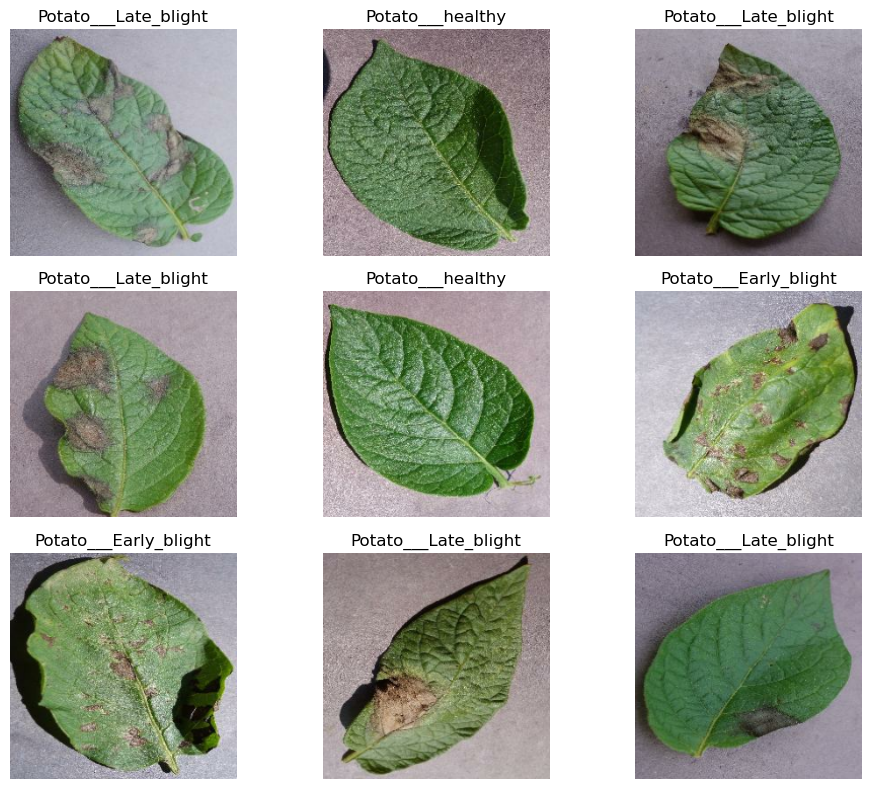

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.tight_layout()
plt.show()

In [18]:
from tensorflow import keras
from tensorflow.keras import layers

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

base_model = tf.keras.applications.MobileNetV2(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights="imagenet"
)
base_model.trainable = False

inputs = keras.Input(shape=IMG_SIZE + (3,))
x = data_augmentation(inputs)
x = tf.keras.applications.mobilenet_v2.preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

model = keras.Model(inputs, outputs)

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 112s 2s/step - accuracy: 0.8037 - loss: 0.5251 - val_accuracy: 0.9302 - val_loss: 0.2316
Epoch 2/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 93s 2s/step - accuracy: 0.9402 - loss: 0.1812 - val_accuracy: 0.9628 - val_loss: 0.1456
Epoch 3/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 89s 2s/step - accuracy: 0.9547 - loss: 0.1351 - val_accuracy: 0.9744 - val_loss: 0.1132
Epoch 4/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 91s 2s/step - accuracy: 0.9698 - loss: 0.0988 - val_accuracy: 0.9814 - val_loss: 0.0958
Epoch 5/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 74s 1s/step - accuracy: 0.9727 - loss: 0.0936 - val_accuracy: 0.9791 - val_loss: 0.0830
Epoch 6/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 93s 2s/step - accuracy: 0.9768 - loss: 0.0731 - val_accuracy: 0.9767 - val_loss: 0.0773
Epoch 7/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 70s 1s/step - accuracy: 0.9791 - loss: 0.0723 - val_accuracy: 0.9814 - val_loss: 0.0711
Epoch 8/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 85s 2s/step - accuracy: 0.9721

In [19]:
import json
from pathlib import Path

MODEL_DIR = Path("../models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

model.save(MODEL_DIR / "plant_disease_model.keras")

with open(MODEL_DIR / "plant_disease_class_names.json", "w") as f:
    json.dump(class_names, f)

print("Model and class names saved.")

Model and class names saved.


In [20]:
import sys
print(sys.executable)
print(sys.version)

C:\Users\grana\anaconda3\python.exe
3.13.9 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 19:09:58) [MSC v.1929 64 bit (AMD64)]
